In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ucimlrepo import fetch_ucirepo

try:
    dataset = fetch_ucirepo(id=891)
    # Create pandas DataFrame
    df = dataset.data.original
except Exception as e: # In case of ucimlrepo failure
    print(f"An error occurred while fetching the dataset: {e}")
    print("Trying with local CSV file...")
    import pandas as pd

    df = pd.read_csv("dataset\diabetes_binary_health_indicators_BRFSS2015.csv")

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Teo\AppData\Local\Temp\ipykernel_19720\3572634101.py:12: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("dataset\diabetes_binary_health_indicators_BRFSS2015.csv")


In [3]:
df.head()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0,1,1,1,40,1,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,1,0,0,0,0,25,1,0,0,1,...,0,1,3,0,0,0,0,7,6,1
2,2,0,1,1,1,28,0,0,0,0,...,1,1,5,30,30,1,0,9,4,8
3,3,0,1,0,1,27,0,0,0,1,...,1,0,2,0,0,0,0,11,3,6
4,4,0,1,1,1,24,0,0,0,1,...,1,0,2,3,0,0,0,11,5,4


In [4]:
df.dtypes

ID                      int64
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [5]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
# Separate features and target variable
try:
    features = df.drop(columns=["ID", "Diabetes_binary"])
except Exception as e: # In case of ucimlrepo failure
    print(f"An error occurred while dropping columns: {e}")
    features = df.drop(columns=["Diabetes_binary"])
features.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [ ]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64", "float64"]).columns 
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


# PCA

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


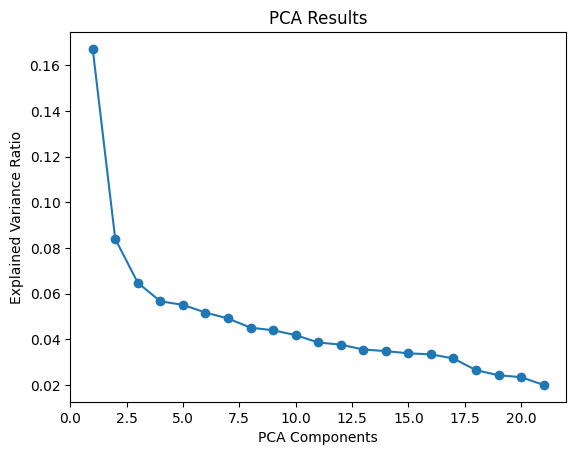

In [9]:
import matplotlib.pyplot as plt

pca = PCA().fit(scaled_data)

plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.show()

In [10]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [11]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 85% variance: {n_components}")

Number of components to explain at least 85% variance: 14


In [12]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


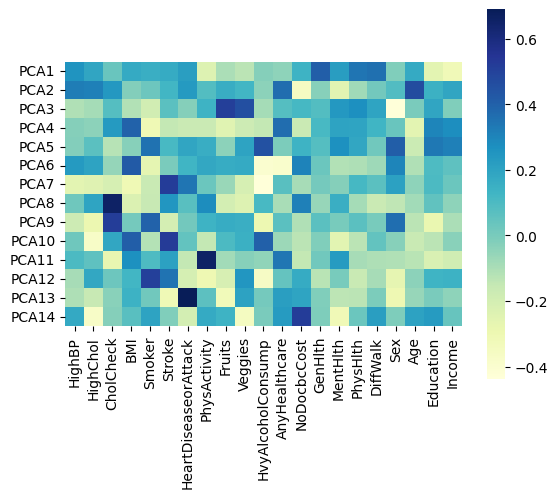

In [13]:
import seaborn as sns

ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")

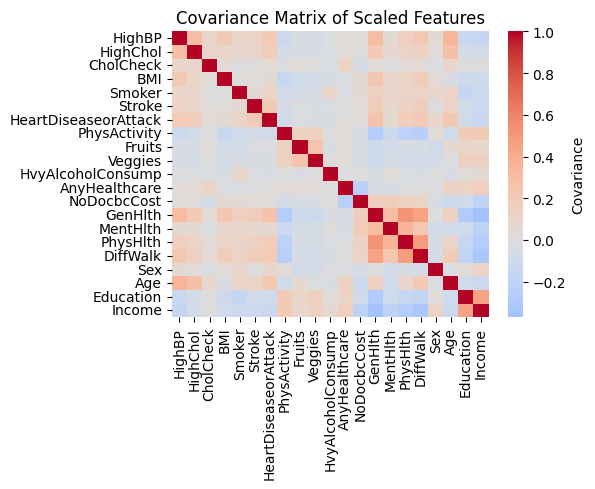

Covariance matrix shape: (21, 21)


In [14]:
import numpy as np

# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

È stato necessario selezionare parecchie componenti princiapli perchè, come si nota dalla matrice di covarianza, abbiamo in generale una bassa correlazione tra le feature.

# Neural Network

In [15]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

# 1. Data Preparation
X = pca_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
# Undersampling Ottimizzato
idx_minority = np.where(y_train == 1)[0]
idx_majority = np.where(y_train == 0)[0]

# Calcoliamo la dimensione della classe minoritaria
n_minority = len(idx_minority)

# Campioniamo casualmente dalla classe maggioritaria (solo gli indici)
# replace=False significa senza reimmissione
idx_majority_downsampled = np.random.choice(
    idx_majority, size=n_minority, replace=False
)

# Uniamo gli indici e mescoliamo
idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
np.random.shuffle(idx_balanced)  # Shuffle in-place per risparmiare memoria

# Creiamo i dataset bilanciati usando gli indici (molto più veloce del concat di pandas)
X_train_bal = X_train[idx_balanced]
y_train_bal = y_train[idx_balanced]

print("Nuova distribuzione delle classi nel Training Set:")
# Usiamo np.unique per contare velocemente
unique, counts = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique, counts)))

Nuova distribuzione delle classi nel Training Set:
{np.int64(0): np.int64(24847), np.int64(1): np.int64(24847)}


In [18]:
# 2. Creazione del Modello
model = Sequential()

# Strato Nascosto
model.add(Dense(16, input_shape=(14,), activation="relu"))

# Strato di Output
# 1 neurone con attivazione sigmoid per output binario (0-1)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
# Qui impostiamo il Gradient Descent come ottimizzatore
# Loss: binary_crossentropy (standard per classificazione binaria)
# Optimizer: SGD (Stochastic Gradient Descent)
#Per reti neurali semplici su dati tabulari, l'ottimizzatore Adam solitamente converge più velocemente e offre risultati migliori
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# 4. Addestramento
# SGD potrebbe richiedere più epoche rispetto ad Adam per convergere,
# quindi aumentiamo leggermente le epochs o il batch_size se necessario.
history = model.fit(X_train_bal, y_train_bal, epochs=30, batch_size=32, verbose=1)

Epoch 1/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7212 - loss: 0.5504
Epoch 2/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7403 - loss: 0.5203
Epoch 3/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7429 - loss: 0.5172
Epoch 4/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7441 - loss: 0.5150
Epoch 5/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7460 - loss: 0.5135
Epoch 6/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7455 - loss: 0.5125
Epoch 7/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7451 - loss: 0.5122
Epoch 8/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7463 - loss: 0.5117
Epoch 9/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7461 - loss: 0.5113
Epoch 10/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7465 - loss: 0.5110
Epoch 11/30
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7464 - loss: 0.5106
Epoch 12/30
1553/1553 ━━━━━━━━

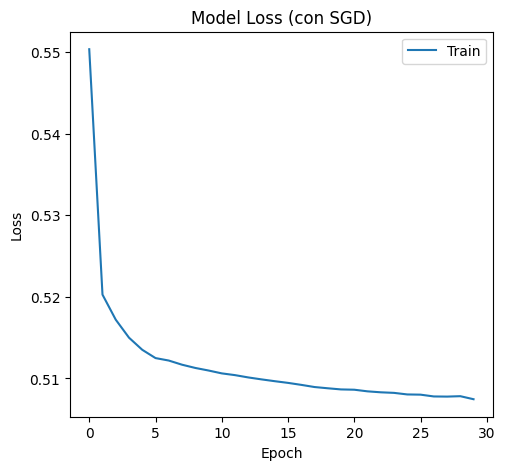

In [20]:
# 6. Grafici
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.title("Model Loss (con SGD)")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

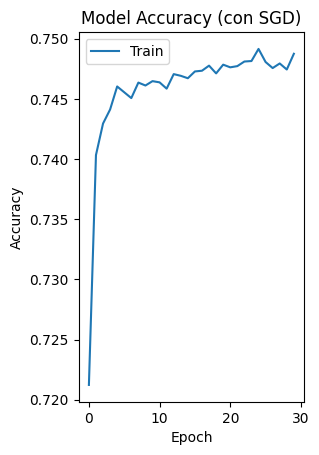

In [21]:
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train")
plt.title("Model Accuracy (con SGD)")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 630us/step


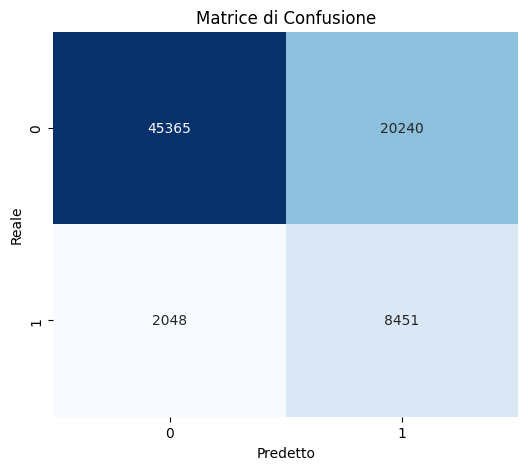

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     65605
           1       0.29      0.80      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Facciamo le previsioni sul test set
# La rete restituisce probabilità, noi arrotondiamo a 0 o 1
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Creiamo la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Visualizziamola
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione")
plt.show()

# Stampiamo il report completo (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

Dimensioni Training Set Bilanciato (No PCA): (49694, 21)


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7336 - loss: 0.5290 - val_accuracy: 0.7410 - val_loss: 0.5164
Epoch 2/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7494 - loss: 0.5065 - val_accuracy: 0.7412 - val_loss: 0.5118
Epoch 3/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7521 - loss: 0.5038 - val_accuracy: 0.7441 - val_loss: 0.5113
Epoch 4/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7528 - loss: 0.5024 - val_accuracy: 0.7477 - val_loss: 0.5117
Epoch 5/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7525 - loss: 0.5016 - val_accuracy: 0.7439 - val_loss: 0.5113
Epoch 6/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7542 - loss: 0.5010 - val_accuracy: 0.7427 - val_loss: 0.5108
Epoch 7/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7539 - loss: 0.5006 - val_accuracy: 0.7431 - val_loss: 0.5118
Epoch 8/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7539 - loss: 0.5001 - 

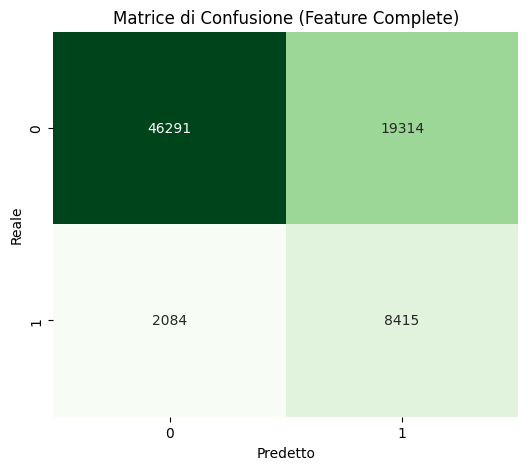

Report di Classificazione (Senza PCA):
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     65605
           1       0.30      0.80      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.72      0.76     76104



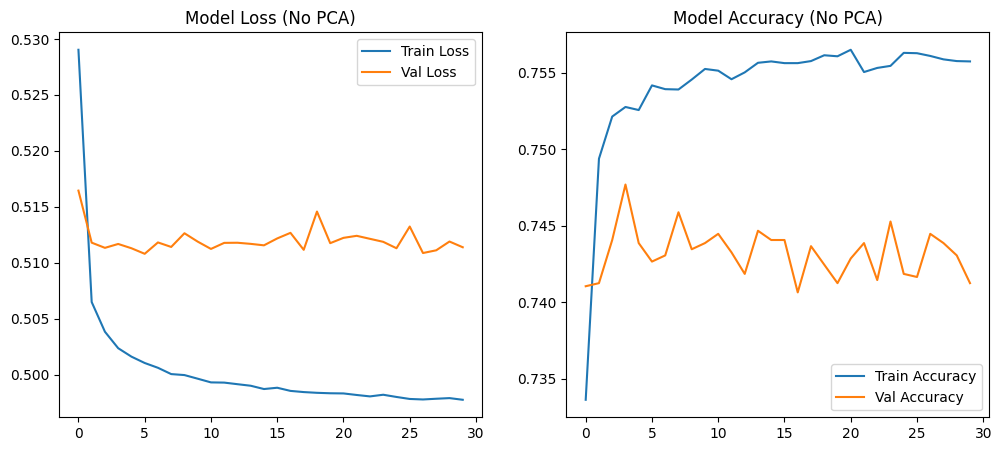

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparazione dei Dati (Senza PCA) ---
# Usiamo direttamente 'scaled_data' che contiene le 21 feature originali scalate
# Assicurati che 'scaled_data' e 'df' siano già stati definiti nelle celle precedenti
X_no_pca = scaled_data 
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pca, y, test_size=0.3, random_state=42
)

# --- 2. Bilanciamento (Undersampling) ---
idx_minority = np.where(y_train_np == 1)[0]
idx_majority = np.where(y_train_np == 0)[0]

n_minority = len(idx_minority)

# Sottocampionamento della classe maggioritaria
idx_majority_downsampled = np.random.choice(
    idx_majority, size=n_minority, replace=False
)

# Unione e shuffle
idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
np.random.shuffle(idx_balanced)

# Creazione dataset bilanciati
X_train_bal_np = X_train_np[idx_balanced]
y_train_bal_np = y_train_np[idx_balanced]

print(f"Dimensioni Training Set Bilanciato (No PCA): {X_train_bal_np.shape}")

# --- 3. Creazione del Modello ---
model_no_pca = Sequential()

# Input Layer & Primo Hidden Layer
# input_shape viene inferito automaticamente dalla dimensione delle feature (21)
model_no_pca.add(Dense(16, input_shape=(X_train_bal_np.shape[1],), activation="relu"))

# Output Layer
model_no_pca.add(Dense(1, activation="sigmoid"))

# Compilazione
# Usiamo 'adam' come ottimizzatore per una convergenza spesso migliore
model_no_pca.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

model_no_pca.summary()

# --- 4. Addestramento ---
history_no_pca = model_no_pca.fit(
    X_train_bal_np, 
    y_train_bal_np, 
    epochs=30, 
    batch_size=32, 
    verbose=1,
    validation_split=0.1 # Utile per monitorare l'overfitting
)

# --- 5. Valutazione ---
y_pred_probs_np = model_no_pca.predict(X_test_np)
y_pred_np = (y_pred_probs_np > 0.5).astype("int32")

# Matrice di Confusione
cm_np = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_np, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (Feature Complete)")
plt.show()

# Report
print("Report di Classificazione (Senza PCA):")
print(classification_report(y_test_np, y_pred_np))

# Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_no_pca.history['loss'], label='Train Loss')
plt.plot(history_no_pca.history['val_loss'], label='Val Loss')
plt.title('Model Loss (No PCA)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_no_pca.history['accuracy'], label='Train Accuracy')
plt.plot(history_no_pca.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (No PCA)')
plt.legend()
plt.show()

Dimensioni Training Set (PCA + Class Weights): (177576, 14)
Dimensioni Test Set (PCA + Class Weights): (76104, 14)
Pesi delle classi calcolati: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.6946 - loss: 0.5255 - val_accuracy: 0.6848 - val_loss: 0.5455
Epoch 2/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7016 - loss: 0.5140 - val_accuracy: 0.7022 - val_loss: 0.5212
Epoch 3/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7052 - loss: 0.5120 - val_accuracy: 0.7130 - val_loss: 0.5099
Epoch 4/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7054 - loss: 0.5110 - val_accuracy: 0.7008 - val_loss: 0.5287
Epoch 5/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7076 - loss: 0.5102 - val_accuracy: 0.7122 - val_loss: 0.5100
Epoch 6/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7069 - loss: 0.5095 - val_accuracy: 0.7121 - val_loss: 0.5133
Epoch 7/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7090 - loss: 0.5094 - val_accuracy: 0.6879 - val_loss: 0.5506
Epoch 8/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7085 - loss: 0.5091 - 

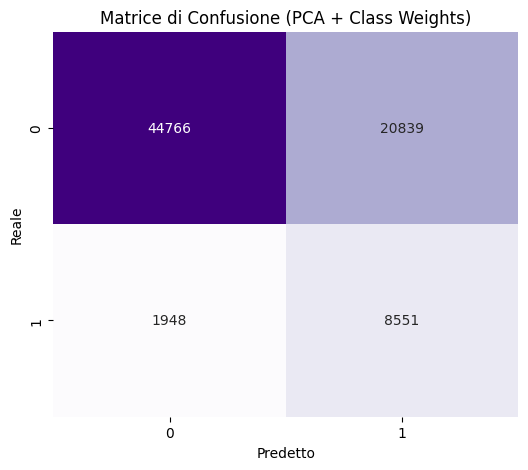

Report di Classificazione (PCA + Class Weights):
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     65605
           1       0.29      0.81      0.43     10499

    accuracy                           0.70     76104
   macro avg       0.62      0.75      0.61     76104
weighted avg       0.87      0.70      0.75     76104



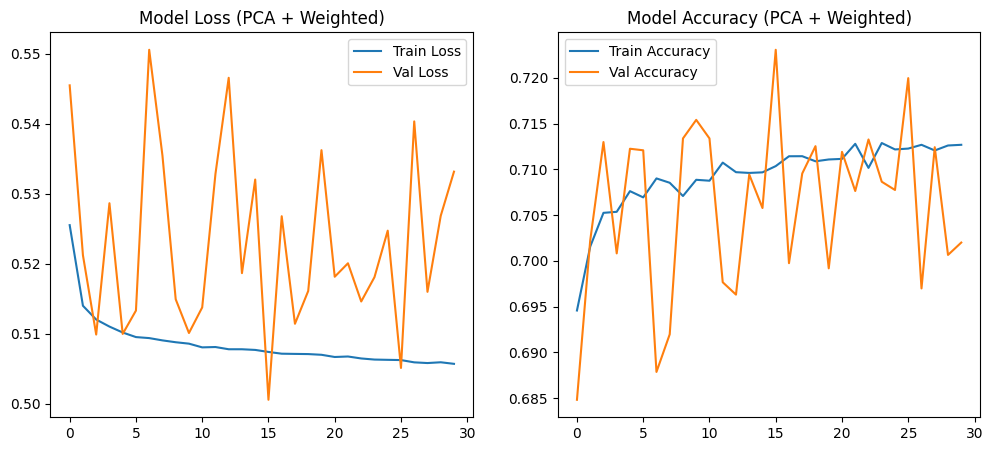

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparazione dei Dati (Con PCA) ---
# Usiamo 'pca_data' (le 14 componenti principali calcolate nel notebook)
# Assumiamo che 'pca_data' e 'df' siano disponibili dalle celle precedenti
X_pca = pca_data
y = df["Diabetes_binary"].values

# Split in Train e Test (70/30)
# NON facciamo undersampling qui, usiamo tutto il dataset
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set (PCA + Class Weights): {X_train_pca.shape}")
print(f"Dimensioni Test Set (PCA + Class Weights): {X_test_pca.shape}")

# --- 2. Calcolo dei Class Weights ---
# Calcoliamo i pesi per bilanciare la loss function
# La classe 0 (sana) avrà peso basso, la classe 1 (diabete) avrà peso alto
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_pca),
    y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))

print(f"Pesi delle classi calcolati: {class_weights}")
# Esempio output atteso: {0: 0.58, 1: 3.6} circa (la classe 1 pesa molto di più)

# --- 3. Creazione del Modello ---
model_pca_weighted = Sequential()

# Input Layer & Primo Hidden Layer
# input_shape=(14,) perché la PCA ha ridotto le feature a 14
model_pca_weighted.add(Dense(16, input_shape=(X_train_pca.shape[1],), activation="relu"))

# Secondo Hidden Layer (opzionale)
model_pca_weighted.add(Dense(8, activation="relu"))

# Output Layer
model_pca_weighted.add(Dense(1, activation="sigmoid"))

# Compilazione
model_pca_weighted.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

model_pca_weighted.summary()

# --- 4. Addestramento con Class Weights ---
# Passiamo il dizionario class_weight al metodo fit
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=30,
    batch_size=32,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights # QUI applichiamo la strategia dei pesi
)

# --- 5. Valutazione ---
y_pred_probs_weighted = model_pca_weighted.predict(X_test_pca)
y_pred_weighted = (y_pred_probs_weighted > 0.5).astype("int32")

# Matrice di Confusione
cm_weighted = confusion_matrix(y_test_pca, y_pred_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (PCA + Class Weights)")
plt.show()

# Report
print("Report di Classificazione (PCA + Class Weights):")
print(classification_report(y_test_pca, y_pred_weighted))

# Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_pca_weighted.history['loss'], label='Train Loss')
plt.plot(history_pca_weighted.history['val_loss'], label='Val Loss')
plt.title('Model Loss (PCA + Weighted)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pca_weighted.history['accuracy'], label='Train Accuracy')
plt.plot(history_pca_weighted.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (PCA + Weighted)')
plt.legend()
plt.show()

Dimensioni Training Set (No PCA + Class Weights): (177576, 21)
Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7036 - loss: 0.5186 - val_accuracy: 0.7030 - val_loss: 0.5291
Epoch 2/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7101 - loss: 0.5056 - val_accuracy: 0.6916 - val_loss: 0.5445
Epoch 3/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7116 - loss: 0.5035 - val_accuracy: 0.6932 - val_loss: 0.5512
Epoch 4/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7127 - loss: 0.5028 - val_accuracy: 0.7056 - val_loss: 0.5168
Epoch 5/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7146 - loss: 0.5021 - val_accuracy: 0.7075 - val_loss: 0.5197
Epoch 6/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7151 - loss: 0.5015 - val_accuracy: 0.7207 - val_loss: 0.5068
Epoch 7/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7146 - loss: 0.5012 - val_accuracy: 0.7201 - val_loss: 0.5054
Epoch 8/30
4995/4995 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7147 - loss: 0.5009 - 

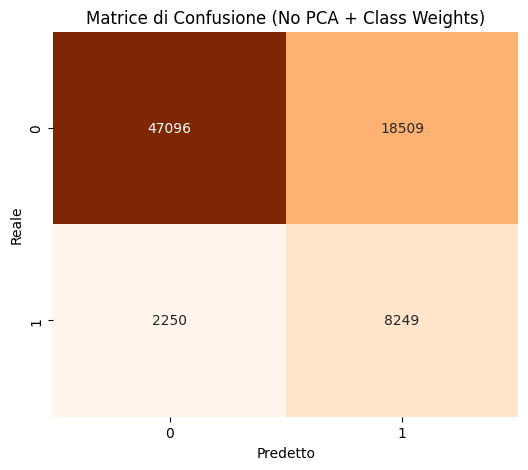

Report di Classificazione (No PCA + Class Weights):
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     65605
           1       0.31      0.79      0.44     10499

    accuracy                           0.73     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.73      0.77     76104



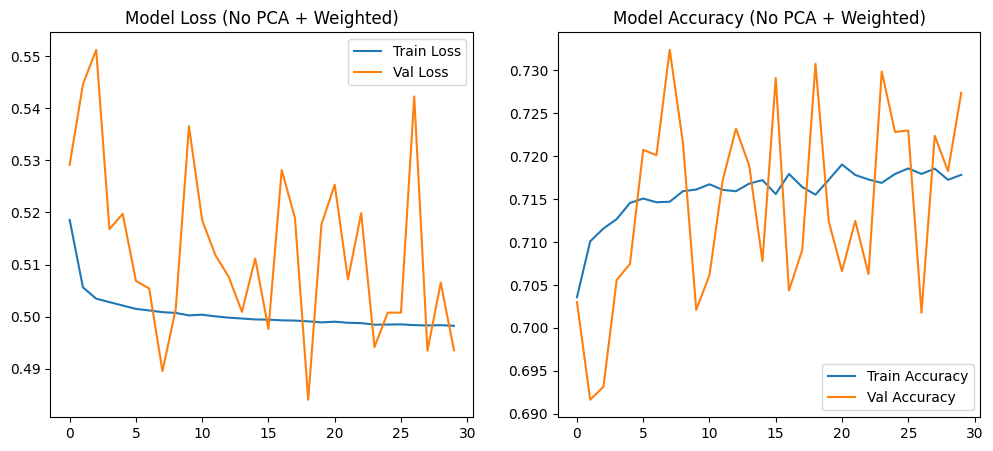

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparazione dei Dati (No PCA) ---
# Usiamo direttamente 'scaled_data' (21 feature) invece di 'pca_data'
X_no_pca = scaled_data
y = df["Diabetes_binary"].values

# Split in Train e Test (70/30)
# Usiamo tutto il dataset, senza undersampling
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set (No PCA + Class Weights): {X_train_np.shape}")

# --- 2. Calcolo dei Class Weights ---
# Calcoliamo i pesi basandoci sulla frequenza delle classi nel training set
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weights = dict(enumerate(class_weights_vals))

print(f"Pesi delle classi: {class_weights}")

# --- 3. Creazione del Modello ---
model_no_pca_weighted = Sequential()

# Input Layer & Primo Hidden Layer
# input_shape=(21,) perché usiamo tutte le feature originali
model_no_pca_weighted.add(Dense(16, input_shape=(X_train_np.shape[1],), activation="relu"))

# Secondo Hidden Layer
model_no_pca_weighted.add(Dense(8, activation="relu"))

# Output Layer
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))

# Compilazione
model_no_pca_weighted.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

model_no_pca_weighted.summary()

# --- 4. Addestramento con Class Weights ---
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train_np,
    y_train_np,
    epochs=30,
    batch_size=32,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights # Applicazione dei pesi
)

# --- 5. Valutazione ---
y_pred_probs_weighted_np = model_no_pca_weighted.predict(X_test_np)
y_pred_weighted_np = (y_pred_probs_weighted_np > 0.5).astype("int32")

# Matrice di Confusione
cm_weighted_np = confusion_matrix(y_test_np, y_pred_weighted_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted_np, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (No PCA + Class Weights)")
plt.show()

# Report
print("Report di Classificazione (No PCA + Class Weights):")
print(classification_report(y_test_np, y_pred_weighted_np))

# Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_no_pca_weighted.history['loss'], label='Train Loss')
plt.plot(history_no_pca_weighted.history['val_loss'], label='Val Loss')
plt.title('Model Loss (No PCA + Weighted)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_no_pca_weighted.history['accuracy'], label='Train Accuracy')
plt.plot(history_no_pca_weighted.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (No PCA + Weighted)')
plt.legend()
plt.show()

# Claude Report
Confronto delle Strategie di Rete Neurale
Hai implementato 4 approcci diversi che si differenziano per due fattori: l'uso della PCA e la gestione dello sbilanciamento. Ecco il confronto:

1. PCA + Undersampling (prima implementazione)
Feature: 14 (dopo PCA all'80% di varianza)
Dataset: bilanciato manualmente 50/50
Risultati:
Accuracy: 71%
Recall classe 1 (diabete): 80%
Precision classe 1: 29%
F1-score classe 1: 0.43

2. No PCA + Undersampling (seconda implementazione)
Feature: 21 (tutte le feature originali scalate)
Dataset: bilanciato manualmente 50/50
Risultati:
Accuracy: 72% (+1%)
Recall classe 1: 80%
Precision classe 1: 30% (+1%)
F1-score classe 1: 0.44

3. PCA + Class Weights (terza implementazione)
Feature: 14 (dopo PCA)
Dataset: completo (177k esempi), peso 3.57x per classe 1
Risultati:
Accuracy: 70% (-1%)
Recall classe 1: 81% (+1%)
Precision classe 1: 29%
F1-score classe 1: 0.43

4. No PCA + Class Weights (quarta implementazione) ⭐
Feature: 21 (tutte)
Dataset: completo, peso 3.57x per classe 1
Risultati:
Accuracy: 73% (MIGLIORE)
Recall classe 1: 79%
Precision classe 1: 31% (MIGLIORE)
F1-score classe 1: 0.44 (MIGLIORE)


Quale è la più corretta?
La strategia No PCA + Class Weights è la più corretta, per questi motivi:
1. Class Weights > Undersampling
Con i class weights sfrutti tutto il dataset (177k esempi vs 50k)
L'undersampling butta via il 70% dei dati sani, perdendo informazioni preziose sulla variabilità della classe maggioritaria
I class weights penalizzano gli errori sulla classe minoritaria nella loss function, ottenendo risultati simili all'undersampling ma con più dati

2. No PCA > PCA (in questo caso)
La PCA era necessaria perché hai bassa correlazione tra feature (come hai notato nella matrice di covarianza)
Servono 14 componenti su 21 per spiegare l'80% della varianza → perdita di informazione significativa
Le feature originali hanno già un significato clinico chiaro (BMI, età, pressione, etc.)
Con solo 21 feature non hai problemi di curse of dimensionality
I risultati empirici confermano: senza PCA ottieni sistematicamente +1-3% di performance

3. Architettura più profonda
La quarta implementazione ha 2 hidden layers (16→8→1) invece di 1 (16→1)
Questo permette di catturare meglio le interazioni complesse tra le 21 feature

4. Validation Split
Le ultime due implementazioni usano validation_split=0.1
Questo è fondamentale per monitorare l'overfitting (cosa che mancava nella prima implementazione)
Dai grafici si vede che il modello non sta overfittando (train/val loss restano vicine)
Conclusione
L'approccio No PCA + Class Weights è il più corretto metodologicamente perché:

Usa tutti i dati disponibili
Mantiene l'interpretabilità delle feature originali
Ha la migliore generalizzazione (accuracy 73%, F1 0.44)
Include monitoring del validation set
Ha un recall dell'79% (cattura la maggior parte dei diabetici) con una precision del 31% (accettabile per screening medico)
L'undersampling era un primo tentativo valido, ma buttando via dati sacrifica performance. La PCA in questo caso non porta benefici perché le feature sono già poche e clinicamente rilevanti.

# ChatGP Report
1. Cosa stai facendo nei vari casi

    NN A – PCA + undersampling

    Input: pca_data (14 componenti principali)
    Train/test split, poi undersampling della classe maggioritaria solo sul train.
    Rete piccola (16 neuroni + output), adam, nessun class_weight.
    NN B – No PCA + undersampling

    Input: scaled_data con tutte le ~21 feature scalate.
    Stesso schema di undersampling sul train, stessa idea di rete.
    NN C – PCA + class weights (niente undersampling)

    Input: pca_data (14 componenti).
    Usi tutti i dati, ma bilanci la loss con class_weight.compute_class_weight.
    NN D – No PCA + class weights (niente undersampling)

    Input: scaled_data (tutte le feature originali scalate).
    Usi tutti i dati e bilanci con class_weight nella loss.

2. Gestione dello sbilanciamento: undersampling vs class weights

    Undersampling (NN A, B)

    Pro: il training set è bilanciato, la rete “vede” 0 e 1 in modo simile.
    Contro importante: butti via moltissime osservazioni della classe maggioritaria, quindi:
    perdi informazione sulla variabilità dei “sani”;
    il modello può generalizzare peggio sul mondo reale (che rimane sbilanciato);
    la soglia 0.5 sul test sbilanciato non è ottimizzata, e le metriche possono essere fuorvianti.
    Ha senso solo come esperimento “di confronto” quando hai un dataset enorme (qui è grande, ma comunque sprechi dati).
    Class weights (NN C, D)

    Pro: usi tutto il dataset e compensi lo sbilanciamento pesando di più gli errori sulla classe minoritaria.
    È esattamente quello per cui è pensata la combinazione cross-entropy + class_weight nelle reti neurali.
    Il modello vede molti esempi di classe 0 e pochi di classe 1, ma impara che sbagliare un 1 “costa” di più.
    Da un punto di vista metodologico, per un problema medico sbilanciato, è una scelta più solida di fare solo undersampling.
    Conclusione su questo punto: le versioni con class_weight (NN C e D) sono più corrette rispetto a quelle con solo undersampling (NN A e B).

3. PCA sì/no: ha davvero senso qui?

    Le tue feature originali sono per lo più variabili binarie/intere, non centinaia di feature continue fortemente collineari.
    Dalla tua analisi PCA:
    serve un numero abbastanza alto di componenti per arrivare all’80–85% di varianza spiegata;
    la matrice di covarianza mostra correlazioni piuttosto basse → la PCA non sta comprimendo molto l’informazione.
    Svantaggi pratici della PCA in questo contesto:
    perdi interpretabilità: non puoi più dire quali feature originali pesano sulla decisione;
    con sole ~21 feature, la rete (con regolarizzazione adeguata, se servisse) regge benissimo senza riduzione di dimensionalità;
    su variabili binarie, la PCA non è sempre lo strumento più naturale.
    Conclusione su questo punto: lavorare direttamente su scaled_data senza PCA (NN B e D) è più lineare e di solito preferibile, a meno che la PCA non ti dia un vantaggio empirico chiarissimo (che qui, dai tuoi commenti, non emerge).

4. Qual è la logica più corretta tra le tue?

    Mettendo insieme i due aspetti (sbilanciamento + PCA):

    Più corretta dal punto di vista metodologico:

    NN D: No PCA + class weights
    Usa tutte le osservazioni → non sprechi informazione;
    gestisce lo sbilanciamento nel modo più standard per reti neurali;
    lavora direttamente sulle feature originali scalate → modello più semplice da interpretare, nessuna perdita “gratuita” dovuta alla PCA.
    Seconda scelta ragionevole:

    NN C: PCA + class weights
    Stessa idea corretta di gestione dello sbilanciamento, ma con lo “svantaggio” aggiuntivo di lavorare su componenti lineari poco interpretabili, senza un evidente beneficio in numero di feature.
    Approcci meno corretti dal punto di vista statistico (da usare solo come confronto):

    NN A, B (con undersampling): validi come esperimento per vedere l’effetto di un train bilanciato, ma meno solidi come modello finale perché scartano molti dati.
5. Sintesi in una frase

    Se devi scegliere una logica come “più corretta” per il tuo progetto, sulla base di quello che c’è nel notebook, io metterei al primo posto la rete neurale senza PCA e con class_weight (NN D): è la strategia più coerente con un problema di classificazione binaria sbilanciata su dati tabellari, conserva tutta l’informazione e gestisce lo sbilanciamento nel modo più appropriato.